In [81]:
import torch
# https://blog.csdn.net/bit452/article/details/109680909

逻辑斯蒂回归虽然叫回归，但是是分类问题<br>
逻辑斯蒂回归和线性模型的明显区别是在线性模型的后面，添加了激活函数(非线性变换)<br>
分布的差异：KL散度，cross-entropy交叉熵(BCE)<br>
预测与标签越接近，BCE损失越小。

### `optimizer.zero_grad()`
清空优化器的梯度缓存是为了避免梯度信息在每个训练周期中累积。<br>

在进行反向传播计算梯度之前，优化器会根据当前的损失值和前一次迭代的参数更新信息来计算梯度。这些梯度值被保存在优化器的梯度缓存中，并用于更新模型的参数。<br>

然而，如果不清空梯度缓存，在下一次计算梯度时，当前周期的梯度会叠加到上一次周期的梯度上，导致梯度信息累积，可能对参数更新产生不良影响，使得模型难以收敛或收敛速度减慢。<br>

因此，为了保证每个训练周期中只使用当前周期的梯度信息，需要在每个周期开始前使用optimizer.zero_grad()方法来清空梯度缓存，确保只计算当前周期的梯度。这样，每个周期的梯度都是基于当前周期内的损失计算得到的。<br>
--- chatgpt ==> https://c2.binjie.fun/#/chat/1689652849274<br>
05 04 的代码思路 跟03 02 01 的相似。

`optimizer`、`criterion`和`model`是深度学习中常见的三个关键组件。<br>

- `optimizer`（优化器）用于定义参数更新的策略，它决定了如何根据损失函数的梯度对模型的参数进行调整。优化器根据模型的当前参数值和损失函数的梯度信息计算参数的更新方向和幅度，然后通过调用optimizer.step()来更新模型的参数。

- `criterion`（损失函数）用于评估模型在训练过程中的性能。损失函数根据模型的预测结果和真实标签之间的差异来计算损失值，用于度量模型的准确性或误差。在训练过程中，优化器使用损失函数的梯度信息来调整模型参数，使得损失函数的值逐渐减小。

- `model`（模型）是具体的神经网络模型，用于学习输入数据的特征表示和输出预测。模型根据输入数据进行前向传播，在每个训练样本上生成输出，并根据损失函数的结果进行反向传播来计算梯度。模型的参数由优化器根据梯度信息进行更新，以最小化损失函数。

因此，这三个组件之间的关系是：模型（model）根据输入数据进行前向传播生成预测结果，损失函数（criterion）根据预测结果和真实标签计算损失值，优化器（optimizer）根据损失函数的梯度信息调整模型的参数。通过迭代这一过程，模型逐渐改进其性能，使得损失函数减小，达到更好的预测结果。

In [82]:
# prepare dataset
x_data = torch.Tensor([ [1], [2], [3]])
y_data = torch.Tensor([ [0], [0], [1]])

# design model using Class
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1,1)

    def forward(self, x):
        y_pred = torch.sigmoid(self.linear(x))
        return y_pred
model = LogisticRegressionModel()

# construct loss and optimizer
criterion = torch.nn.BCELoss(size_average=False)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

# training cycle
for epoch in range(1000): # 100次时图变化很大，1000时比较稳定
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("w = ", model.linear.weight.item())
print("b = ", model.linear.bias.item())

# test
x_test = torch.Tensor([4.0])
y_test = model(x_test)
print(y_test.data)

0 2.435877799987793
1 2.4312472343444824
2 2.426766872406006
3 2.422426223754883
4 2.418214797973633
5 2.4141247272491455
6 2.410146713256836
7 2.406273365020752
8 2.4024970531463623
9 2.398810386657715
10 2.3952078819274902
11 2.3916828632354736
12 2.388230323791504
13 2.38484525680542
14 2.3815221786499023
15 2.3782575130462646
16 2.375046968460083
17 2.371886730194092
18 2.3687729835510254
19 2.3657031059265137
20 2.36267352104187
21 2.3596816062927246
22 2.3567252159118652
23 2.3538014888763428
24 2.3509085178375244
25 2.3480443954467773
26 2.3452064990997314
27 2.3423943519592285
28 2.3396050930023193
29 2.3368380069732666
30 2.3340911865234375
31 2.331364154815674
32 2.3286547660827637
33 2.325963020324707
34 2.323287010192871
35 2.3206262588500977
36 2.3179798126220703
37 2.315347194671631
38 2.312727451324463
39 2.31011962890625
40 2.307523250579834
41 2.3049378395080566
42 2.302363395690918
43 2.2997982501983643
44 2.297243118286133
45 2.2946972846984863
46 2.2921600341796875


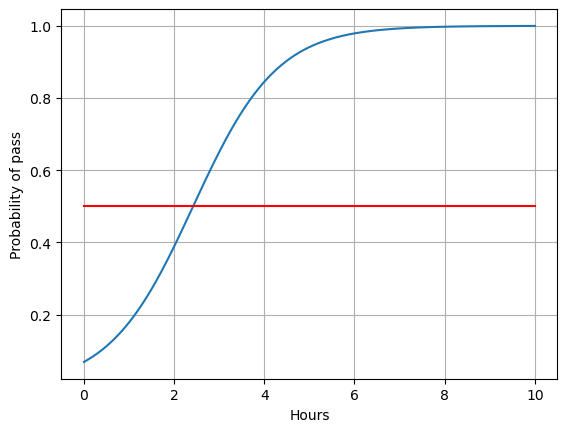

In [83]:
import numpy as np 
import matplotlib.pyplot as plt 

x = np.linspace(0, 10, 200)
x_t = torch.Tensor(x).view(200, 1)
y_t = model(x_t)
# print(y_t)
y = y_t.data.numpy()
# print(y)
plt.plot(x,y)
plt.plot([0, 10], [0.5, 0.5], c = "r")
plt.xlabel("Hours")
plt.ylabel("Probability of pass")
plt.grid()
plt.show()